In [52]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR

In [6]:
prices = pd.read_csv(
    RAW_DATA_DIR / "prices.csv",
    index_col=0,
    parse_dates=True,
)

prices.head()

,AAPL,JNJ,JPM,WMT,XOM
Date,,,,,
2015-01-02,24.171753,75.737396,46.066795,23.072313,56.777897
2015-01-05,23.490799,75.208405,44.636639,23.005156,55.224365
2015-01-06,23.493015,74.838844,43.479267,23.182432,54.930779
2015-01-07,23.822432,76.490967,43.545612,23.797512,55.487377
2015-01-08,24.737753,77.092415,44.518703,24.299795,56.410923


In [7]:
prices.describe()

,AAPL,JNJ,JPM,WMT,XOM
count,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000
mean,106.036035,122.945496,118.220400,42.301034,67.489028
std,74.119445,29.552029,65.220473,23.054242,24.852065
min,20.548145,67.197998,40.088215,15.446122,23.670290
25%,36.551956,101.613564,73.923767,23.779383,51.557171
50%,88.231133,123.992496,98.234600,38.532902,56.079453
75%,168.189362,147.131313,139.154129,48.258386,94.454554
max,285.413116,210.779739,324.561249,116.050972,118.610596


### Visualizing Prices

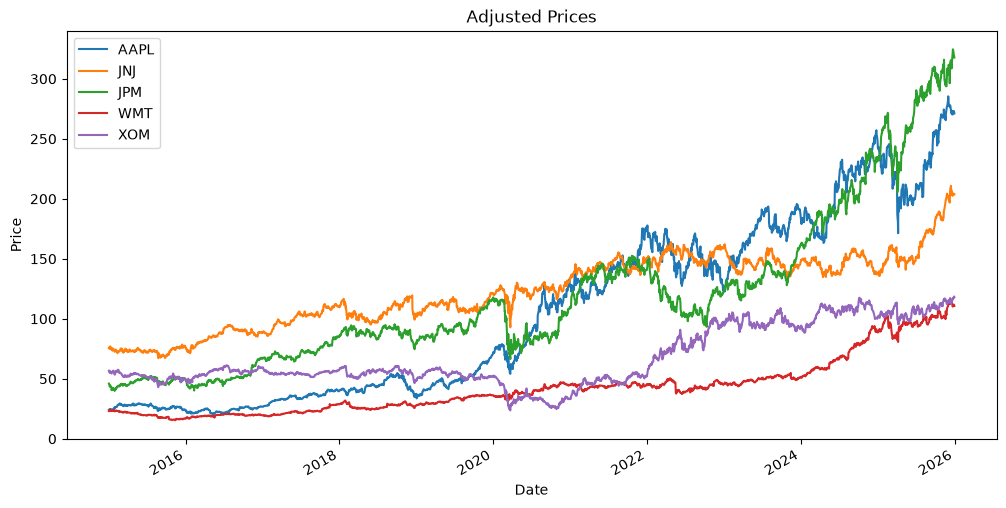

In [8]:
prices.plot(
    figsize=(12, 6),
    title="Adjusted Prices",
)

plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Calculating Portfolio Value at t

In [9]:
weights = {
    "AAPL": 0.20,
    "JPM": 0.20,
    "XOM": 0.20,
    "JNJ": 0.20,
    "WMT": 0.20,
}

normalized_prices = prices / prices.iloc[0]

portfolio_value = normalized_prices.mul(
    pd.Series(weights),
    axis=1
).sum(axis=1)

portfolio_value.name = "Portfolio"

portfolio_value.head()

Date
2015-01-02    1.000000
2015-01-05    0.980705
2015-01-06    0.975226
2015-01-07    0.989894
2015-01-08    1.010888
Name: Portfolio, dtype: float64

### Plotting Portfolio Value

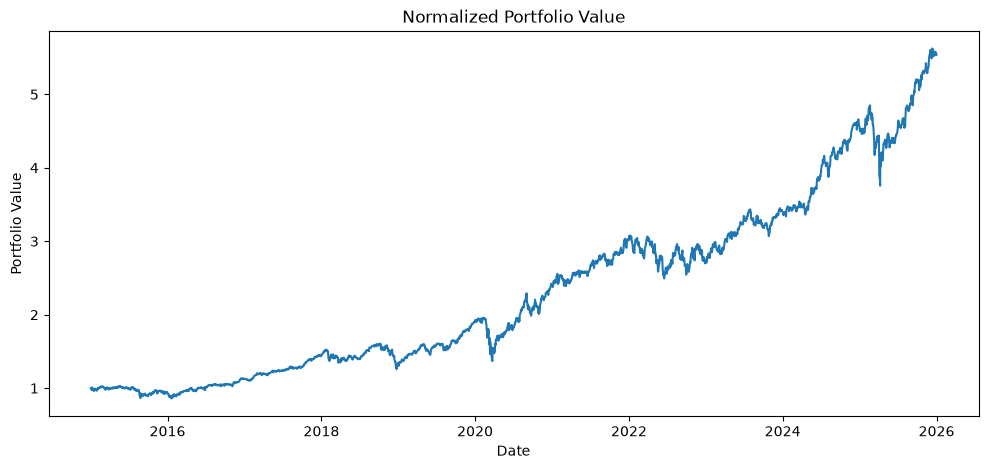

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(portfolio_value)

plt.title("Normalized Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.show()

### Calculating Portfolio return

In [11]:
portfolio_returns = np.log(
    portfolio_value / portfolio_value.shift(1)
).dropna()

portfolio_returns.name = "Portfolio Return"

Annualized Volatility

In [12]:
annualized_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

annualized_volatility

np.float64(0.18396530013831025)

Return Distribution

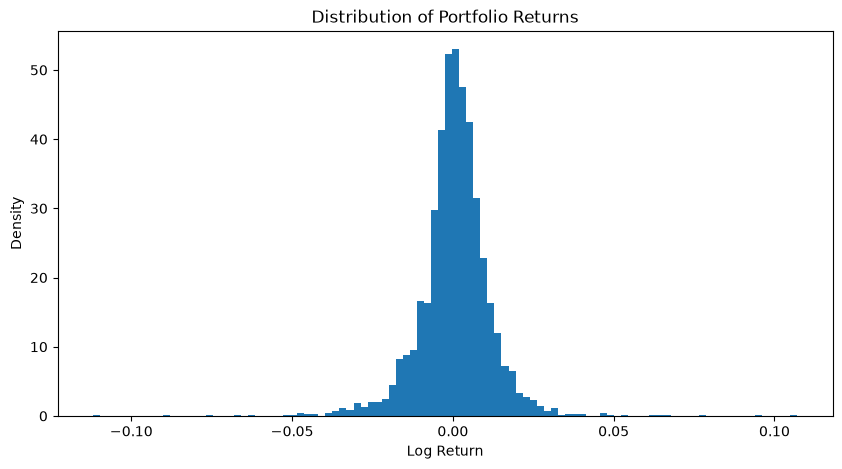

In [48]:
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_returns,
    bins=100,
    density=True
)

plt.title("Distribution of Portfolio Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")

plt.show()

### Observations:

- Centered Around 0
- Presence of Extreme Observations
- Asymmetric Tail (longer left tail)

### Comparison with Gaussian Distribution

In [14]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()    

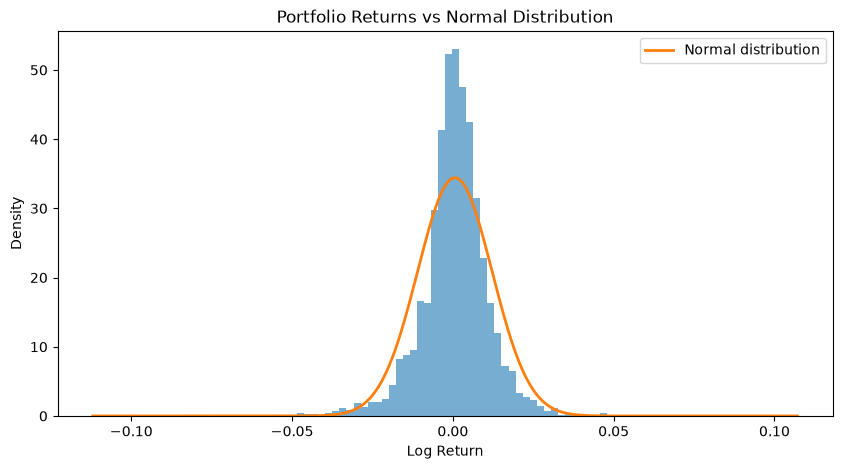

In [46]:
from scipy.stats import norm

x = np.linspace(
    portfolio_returns.min(),
    portfolio_returns.max(),
    500
)

plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_returns,
    bins=100,
    density=True,
    alpha=0.6
)

plt.plot(
    x,
    norm.pdf(x, mu, sigma),
    linewidth=2,
    label="Normal distribution"
)

plt.title("Portfolio Returns vs Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()

plt.show()

In [16]:
from scipy.stats import skew, kurtosis

print("Mean:", portfolio_returns.mean())
print("Std:", portfolio_returns.std())
print("Skewness:", skew(portfolio_returns))
print("Excess kurtosis:", kurtosis(portfolio_returns))

Mean: 0.0006188836405732513
Std: 0.011588724619793458
Skewness: -0.21908763949313065
Excess kurtosis: 12.8553761912413


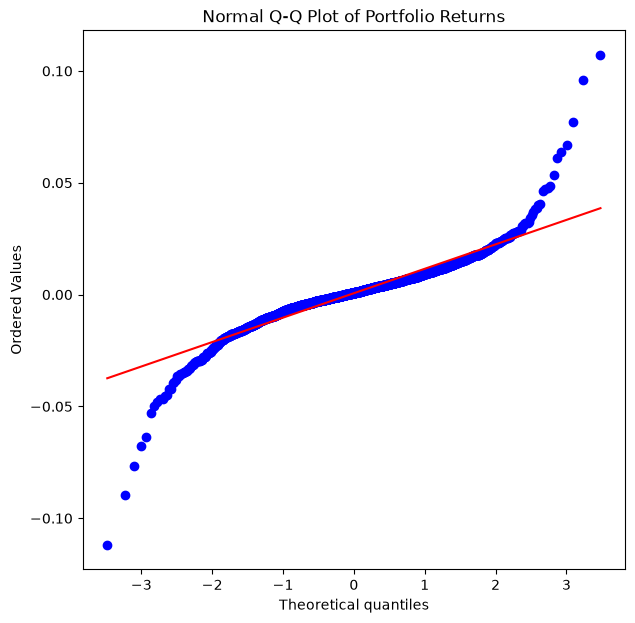

In [17]:
import scipy.stats as stats

plt.figure(figsize=(7, 7))

stats.probplot(
    portfolio_returns,
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot of Portfolio Returns")

plt.show()

Clearly having heavier tails.

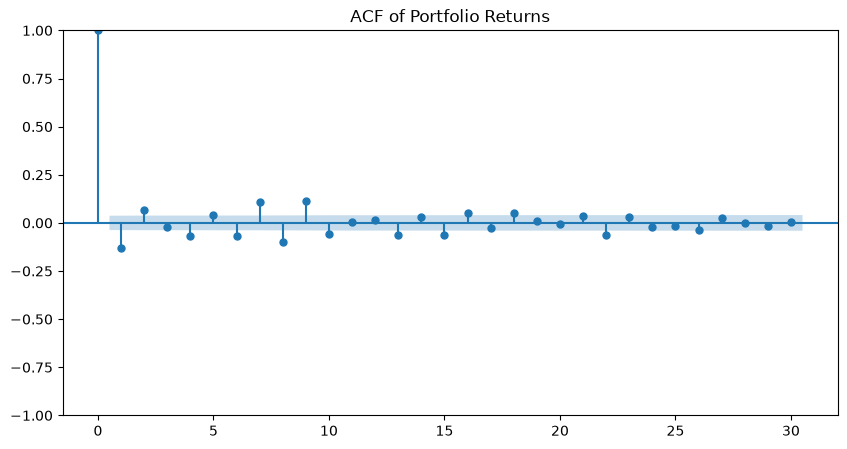

In [20]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    portfolio_returns,
    lags=30,
    alpha=0.05,
    ax = ax
)

plt.title("ACF of Portfolio Returns")

plt.show()

Unlike theory, which says no auto-correlation would be observed between log returns, we can see few signicant auctocorrelation upto lag 10 which can be due to chance.

Autocorrelation of Absolute Returns

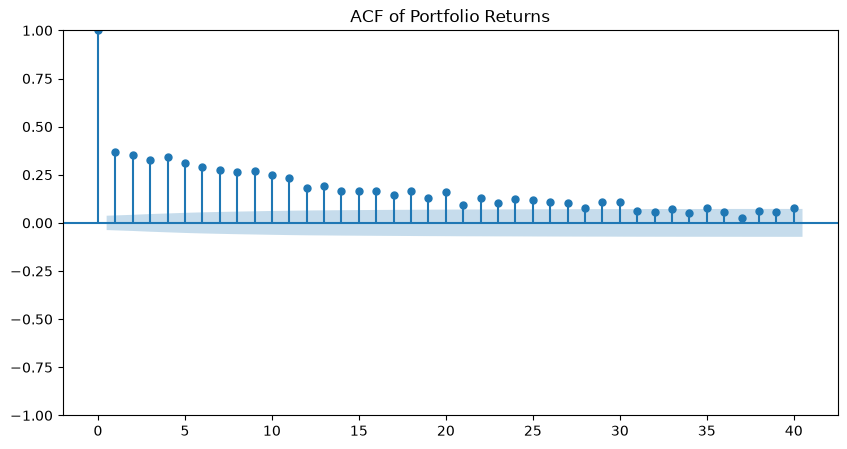

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    abs(portfolio_returns),
    lags=40,
    alpha=0.05,
    ax = ax
)

plt.title("ACF of Portfolio Returns")

plt.show()

Bingo! huge correlation. significant correlation are observed till lag 20.

Autocorrelation of Squared Returns

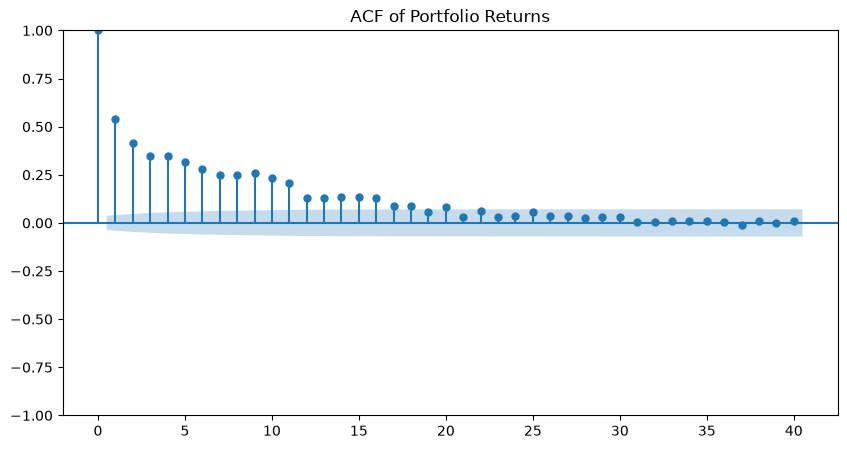

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    abs(portfolio_returns**2),
    lags=40,
    alpha=0.05,
    ax = ax
)

plt.title("ACF of Portfolio Returns")

plt.show()

Correlation exist between squared returns, however not as good as observed among absolute returns

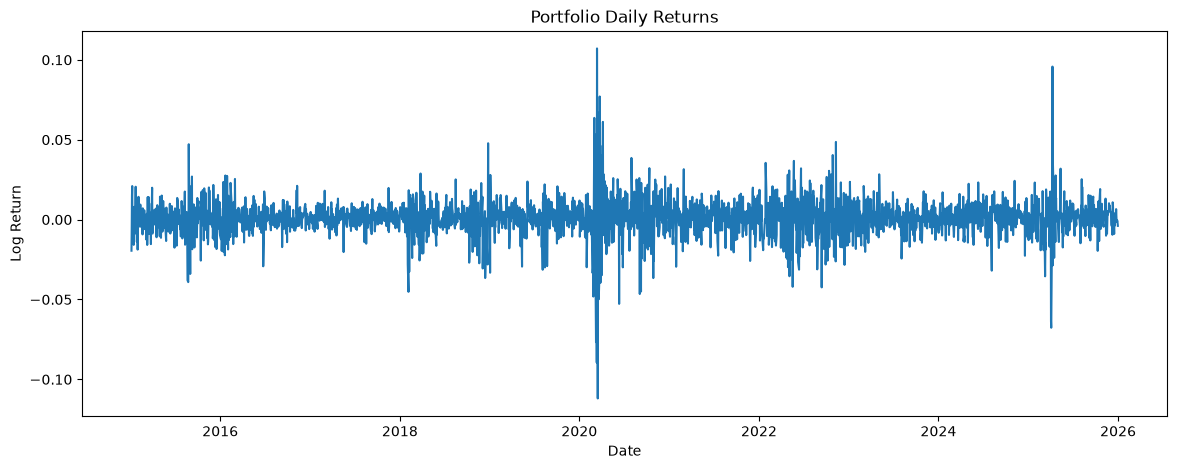

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(portfolio_returns)

plt.title("Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.show()

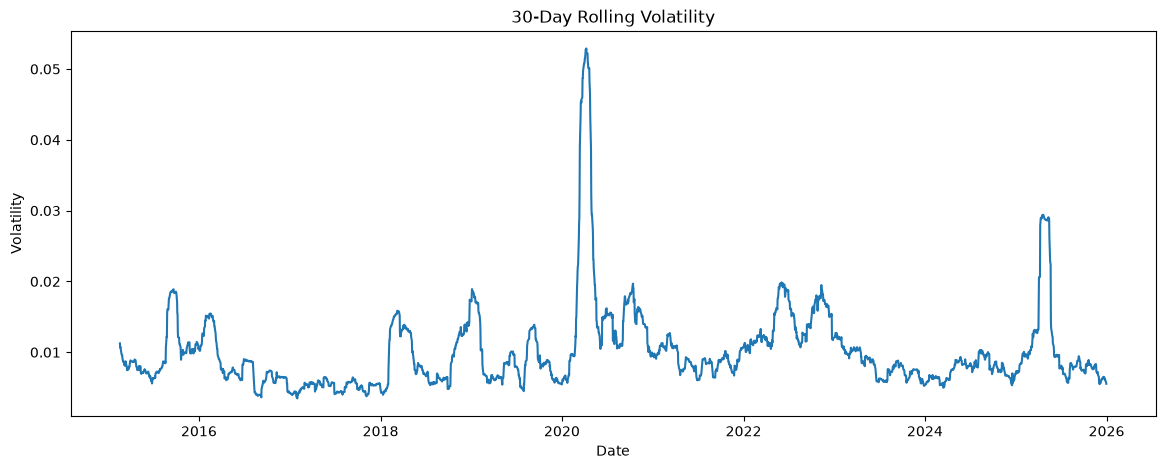

In [26]:
rolling_volatility = portfolio_returns.rolling(30).std()

plt.figure(figsize=(14, 5))

plt.plot(rolling_volatility)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

In [27]:
asset_returns = np.log(
    prices / prices.shift(1)
).dropna()

In [36]:
asset_returns

,AAPL,JNJ,JPM,WMT,XOM
Date,,,,,
2015-01-05,-0.028576,-0.007009,-0.031537,-0.002915,-0.027743
2015-01-06,0.000094,-0.004926,-0.026271,0.007676,-0.005330
2015-01-07,0.013924,0.021836,0.001525,0.026186,0.010082
2015-01-08,0.037703,0.007832,0.022100,0.020887,0.016507
2015-01-09,0.001072,-0.013723,-0.017540,-0.012457,-0.001411
...,...,...,...,...,...
2025-12-24,0.005310,0.009672,0.009892,0.006382,-0.001676
2025-12-26,-0.001498,-0.000722,-0.003835,0.001164,-0.000923
2025-12-29,0.001316,-0.000337,-0.012768,0.007045,0.011851


Looking for any abnormalities in assetwise returns

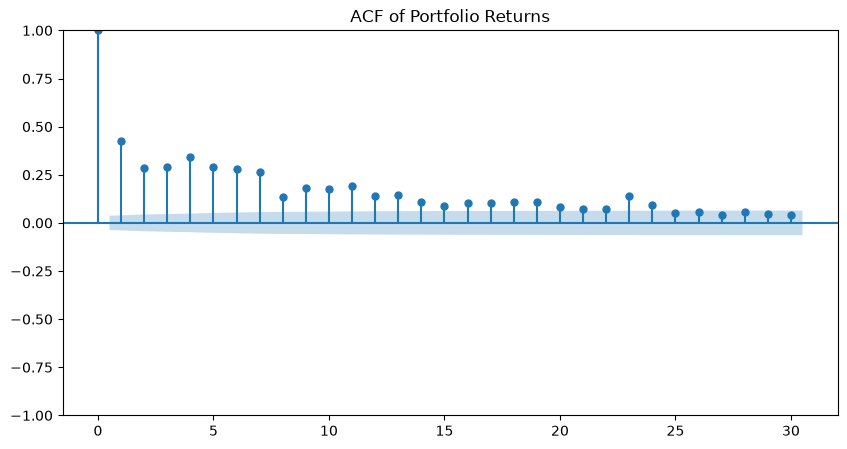

In [57]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(
    abs(asset_returns["JPM"]**2),
    lags=30,
    alpha=0.05,
    ax = ax
)

plt.title("ACF of Portfolio Returns")

plt.show()

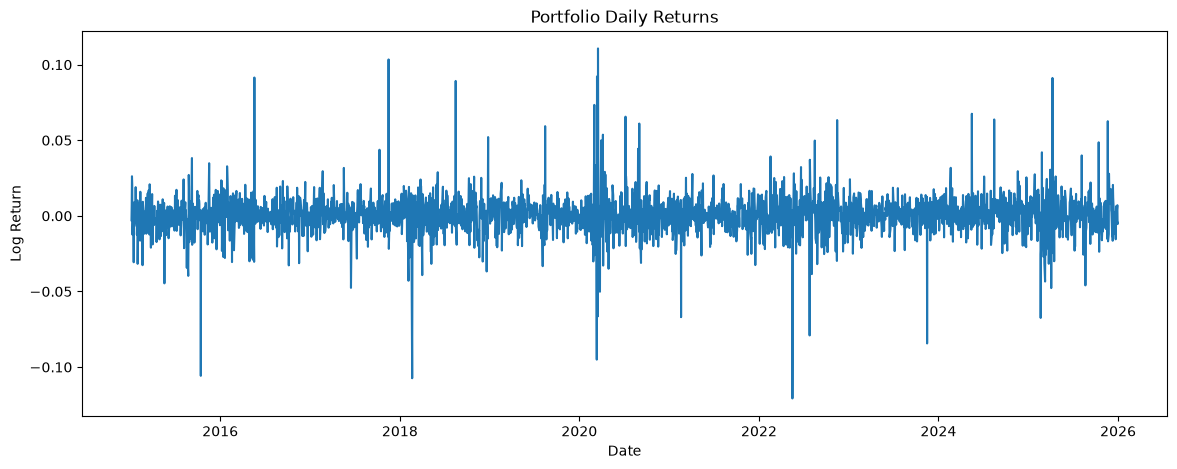

In [44]:
plt.figure(figsize=(14, 5))

plt.plot(asset_returns["WMT"])

plt.title("Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.show()

In [50]:
correlation_matrix = asset_returns.corr()

correlation_matrix

,AAPL,JNJ,JPM,WMT,XOM
AAPL,1.000000,0.316591,0.426560,0.320457,0.312960
JNJ,0.316591,1.000000,0.371629,0.335199,0.310834
JPM,0.426560,0.371629,1.000000,0.262780,0.544584
WMT,0.320457,0.335199,0.262780,1.000000,0.193381
XOM,0.312960,0.310834,0.544584,0.193381,1.000000


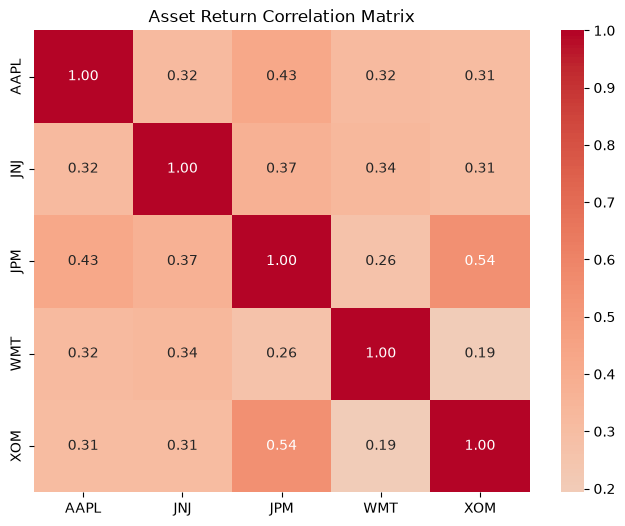

In [53]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Asset Return Correlation Matrix")

plt.show()

Annualized volatility for each asset

In [56]:
asset_volatility = asset_returns.std() * np.sqrt(252)
print("Individual asset volatility:")
print(asset_volatility)

print("\nPortfolio volatility:")
print(portfolio_returns.std() * np.sqrt(252))

Individual asset volatility:
AAPL    0.288191
JNJ     0.182257
JPM     0.271121
WMT     0.214944
XOM     0.274332
dtype: float64

Portfolio volatility:
0.18396530013831025


In [58]:
portfolio_returns.to_csv(
    "../data/processed/portfolio_returns.csv"
)
asset_returns.to_csv(
    "../data/processed/asset_returns.csv"
)